In [1]:
import tensorflow as tf

print(tf.__version__)

2.9.1


In [ ]:
from tensorflow.keras.layers import Conv2D, Conv1D, MaxPool2D, MaxPool1D, Flatten, Dense, Input, Dropout
from tensorflow.keras.activations import relu, softmax
from tensorflow.keras import Sequential

In [3]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import json
import os

In [4]:
with open("../.env") as f:
    for line in f:
        key, value = line.strip().split("=", 1)
        os.environ[key] = value.strip('"')

## Data Preparation

In [5]:
data_path = os.getenv("DATA_PATH")
print(data_path)

C:/Users/slime/Documents/data/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5


In [6]:
# # leads to OOM when loading entire dataset into memory

# with h5py.File(data_path, 'r') as f:
#     # 1. Check what datasets exist inside the file
#     print("Keys available:", list(f.keys()))

#     # 2. Access the target dataset by its key name
#     X = f['X'][:]
#     Y = f['Y'][:]
#     Z = f['Z'][:]

# print(X.shape)
# print(Y.shape)
# print(Z.shape)

In [7]:
# X[:2], Y[:2], Z[:2]

In [ ]:
# lazy loading with `yield` and `tf.data.Dataset.from_generator`

train_size = 0

SEED=42
SHUFFLE_BUFFER = 512
BATCH_SIZE = 32
EPS = 1e-6

DATA_RATIO = 0.01 # dont use 2.5 million points on this laptop
TRAIN_RATIO = 0.8

MODULATIONS = ['OOK',
            '4ASK',
            '8ASK',
            'BPSK',
            'QPSK',
            '8PSK',
            '16PSK',
            '32PSK',
            '16APSK',
            '32APSK',
            '64APSK',
            '128APSK',
            '16QAM',
            '32QAM',
            '64QAM',
            '128QAM',
            '256QAM',
            'AM-SSB-WC',
            'AM-SSB-SC',
            'AM-DSB-WC',
            'AM-DSB-SC',
            'FM',
            'GMSK',
            'OQPSK']
SNRS = np.arange(-20, 32, 2)
FRAMES_PER_MODULATION_SNR = 4096

def make_split_indices(
    path,
    data_ratio=DATA_RATIO,
    train_ratio=TRAIN_RATIO,
    snr_lower=-20,
    snr_upper=30,
):
    if not 0 < data_ratio <= 1:
        raise ValueError("data_ratio must be in the range (0, 1]")
    if not 0 < train_ratio < 1:
        raise ValueError("train_ratio must be in the range (0, 1)")
    if snr_lower > snr_upper:
        raise ValueError("snr_lower must be less than or equal to snr_upper")

    selected_snr_indices = [
        snr_index for snr_index, snr in enumerate(SNRS)
        if snr_lower <= snr <= snr_upper
    ]
    if not selected_snr_indices:
        raise ValueError(f"No SNR values found between {snr_lower} and {snr_upper} dB")

    expected_frames = len(MODULATIONS) * len(SNRS) * FRAMES_PER_MODULATION_SNR
    with h5py.File(path, "r") as hf:
        if len(hf["X"]) != expected_frames:
            raise ValueError(f"Expected {expected_frames} frames, found {len(hf['X'])}")

    samples_per_group = int(FRAMES_PER_MODULATION_SNR * data_ratio)
    if samples_per_group < 2:
        raise ValueError("data_ratio must select at least 2 frames per modulation-SNR group")

    rng = np.random.default_rng(SEED)
    train_parts = []
    test_parts = []

    for modulation_index in range(len(MODULATIONS)):
        for snr_index in selected_snr_indices:
            group_start = (
                (modulation_index * len(SNRS) + snr_index)
                * FRAMES_PER_MODULATION_SNR
            )
            group_indices = np.arange(group_start, group_start + FRAMES_PER_MODULATION_SNR)
            group_indices = rng.choice(group_indices, size=samples_per_group, replace=False)
            rng.shuffle(group_indices)

            split = int(samples_per_group * train_ratio)
            train_parts.append(group_indices[:split])
            test_parts.append(group_indices[split:])

    train_indices = np.concatenate(train_parts)
    test_indices = np.concatenate(test_parts)
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return train_indices, test_indices

def hdf5_generator(path, indices, train=True):
    with h5py.File(path, "r") as hf:
        X = hf["X"]
        Y = hf["Y"]

        if train:
            print(f"Training data:", len(indices), "samples")
        else:
            print(f"Testing data:", len(indices), "samples")

        for i in indices:
            x = X[i].astype(np.float32)            # (1024,2)
            y = Y[i].astype(np.int32)              # (24,)

            yield x, y

def hdf5_generator_snr(path, indices):
    with h5py.File(path, "r") as hf:
        Z = hf["Z"]

        for i in indices:
            z = Z[i].astype(np.int32)              # (1,)

            yield z

# output_sig = (
#     tf.TensorSpec(shape=(1024, 2), dtype=tf.float32, name="feature"),
#     tf.TensorSpec(shape=(24,), dtype=tf.int32, name="label"),
# )

output_sig_snr = tf.TensorSpec(shape=(1,), dtype=tf.int32, name="snr")

def _prep(x, y):
    # mean = tf.reduce_mean(x, axis=0, keepdims=True)   # (1,2)
    # std = tf.math.reduce_std(x, axis=0, keepdims=True)
    # x = (x - mean) / (std + EPS)
    # x = tf.expand_dims(x, -1)                          # (1024,2,1) for convolution
    # y = tf.cast(y, tf.float32)
    x = tf.reshape(x, (32, 32, 2))
    x1 = x[::0]
    x2 = x[::1]

    return x1, x2, y

train_indices, test_indices = make_split_indices(data_path,
                                                 data_ratio=DATA_RATIO,
                                                 train_ratio=TRAIN_RATIO,
                                                 snr_lower=-4)
train_ds = tf.data.Dataset.from_generator(lambda: hdf5_generator(data_path, train_indices, train=True))
                                        #   output_signature=output_sig)
train_ds = (
    train_ds.map(_prep,
                 num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(SHUFFLE_BUFFER, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_generator(lambda: hdf5_generator(data_path, test_indices, train=False))
                                        #  output_signature=output_sig)
test_ds = (
    test_ds.map(_prep,
                num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE)
)

train_ds_snr = tf.data.Dataset.from_generator(lambda: hdf5_generator_snr(data_path, train_indices),
                                        output_signature=output_sig_snr)
train_ds_snr = (
    train_ds_snr.batch(BATCH_SIZE)
    # .shuffle(SHUFFLE_BUFFER, seed=SEED)
                .prefetch(tf.data.AUTOTUNE)
)

In [69]:
for feature, label in train_ds.take(1):
    print("Feature:", feature.shape, feature)
    print("Label:", label.shape, label)
    # print("SNR:", snr.shape, snr[0])

for snr in train_ds_snr.take(1):
    print(snr)

Training data: 13824 samples
Feature: (32, 32, 32, 2) tf.Tensor(
[[[[ 9.67017055e-01 -1.12760925e+00]
   [ 8.29214633e-01 -9.64744091e-01]
   [ 3.71436507e-01 -5.55177152e-01]
   ...
   [-3.10566574e-02 -9.58825350e-02]
   [ 1.57429278e-01  3.81570369e-01]
   [ 3.89365815e-02  9.11456764e-01]]

  [[-3.06282546e-02  7.55128205e-01]
   [-9.49009597e-01  1.11384022e+00]
   [-6.39819086e-01  8.50003719e-01]
   ...
   [-3.24767768e-01  1.50177300e+00]
   [-1.13559031e+00  3.99516493e-01]
   [-2.44043559e-01  8.52956772e-01]]

  [[-4.48978879e-03  1.47864711e+00]
   [-8.03741872e-01  1.08134830e+00]
   [-2.85452008e-01  9.98321950e-01]
   ...
   [-4.28848386e-01  2.81273901e-01]
   [-5.28501034e-01  2.86535565e-02]
   [ 1.51431292e-01 -1.01408705e-01]]

  ...

  [[ 6.96850955e-01 -6.70542955e-01]
   [-6.76005304e-01 -6.25936389e-01]
   [ 5.71216226e-01 -7.13413715e-01]
   ...
   [-4.45945501e-01  1.11215138e+00]
   [-1.98607728e-01  1.12105048e+00]
   [-7.22566187e-01  7.44807780e-01]]

  [[

In [45]:
fixed_classes = json.load(open("../data_labels/classes-fixed.json", 'r'))
print(fixed_classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [12]:
# source: visualize modulations
# https://www.kaggle.com/code/suyashkumarbhagat/radio-ml-2018-data-visualisation

# Function to find the indices of a specific modulation type
def find_modulation_indices(modulation_name, classes_fixed):
    modulation_index = classes_fixed.index(modulation_name)
    indices = [i for i, label in enumerate(Y) if np.argmax(label) == modulation_index]
    return indices

def clean_classes(file_path):
    with open(file_path) as f:
        lines = f.readlines()
    classes_fixed = []
    for line in lines:
        if "|" in line and not line.strip().startswith("#"):
            parts = line.split("|")
            if len(parts) == 4:
                fixed_class = parts[3].strip().strip("'")
                if fixed_class and fixed_class not in ["Fixed"]:
                    classes_fixed.append(fixed_class)
    return classes_fixed

def find_modulation_snr_indices(modulation_name, snr_level, classes_fixed, Y, Z):
    modulation_index = classes_fixed.index(modulation_name)
    indices = [i for i, (label, snr) in enumerate(zip(Y, Z)) if np.argmax(label) == modulation_index and snr == snr_level]
    return indices

def plot_signals_by_modulation_snr(modulation_name, snr_level, num_samples):
    indices = find_modulation_snr_indices(modulation_name, snr_level, fixed_classes, Y, Z)
    if len(indices) < num_samples:
        print(f"Not enough samples for {modulation_name} with SNR {snr_level} dB. Found only {len(indices)} samples.")
        return

    samples = np.random.choice(indices, num_samples, replace=False)

    for sample in samples:
        plt.figure(figsize=(30, 3))

        I_phase = X[sample, :, 0]
        Q_phase = X[sample, :, 1]
        magnitude = np.sqrt((I_phase**2) + (Q_phase**2))

        plt.subplot(1, 3, 1)
        plt.plot(I_phase)
        plt.title(f'{modulation_name} - In-phase (I) (SNR: {snr_level} dB)')

        plt.subplot(1, 3, 2)
        plt.plot(Q_phase)
        plt.title(f'{modulation_name} - Quadrature-phase (Q) (SNR: {snr_level} dB)')

        plt.subplot(1, 3, 3)
        plt.plot(magnitude)
        plt.title(f'{modulation_name} - Magnitude (SNR: {snr_level} dB)')

        plt.tight_layout()
        plt.show()

In [ ]:
#Modulations-['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM',
#              '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
"""modulation_type = '4ASK'
snr_value = 20
num_samples_to_plot = 2 """
#plot_signals_by_modulation_snr(modulation_type, snr_value, num_samples_to_plot)


# plot_signals_by_modulation_snr('4ASK', 24, 1)
# plot_signals_by_modulation_snr('128APSK', 24, 1)
# plot_signals_by_modulation_snr('16QAM', 24, 1)
# plot_signals_by_modulation_snr('256QAM', 24, 1)
# plot_signals_by_modulation_snr('AM-SSB-SC', 24, 1)
# plot_signals_by_modulation_snr('FM', 24, 1)
# plot_signals_by_modulation_snr('GMSK', 24, 1)
# plot_signals_by_modulation_snr('OQPSK', 24, 1)

"modulation_type = '4ASK'  \nsnr_value = 20  \nnum_samples_to_plot = 2 "

## Modelling Experiments

In [ ]:
import tensorflow.keras as tk
import keras
from keras.layers import LeakyReLU

def create_model():
    learning_rate = 0.0001
    i_input = keras.layers.Input(shape=(32,32,1))
    q_input = keras.layers.Input(shape=(32,32,1))

    cnn_q_1 = tk.layers.Conv2D(64, 3, activation=LeakyReLU(alpha=0.1))(q_input)
    cnn_q_1_2 = tk.layers.Conv2D(64, 3, activation=LeakyReLU(alpha=0.1))(cnn_q_1)
    pool_q_1 = tk.layers.MaxPool2D(pool_size=3, strides=2, padding='valid')(cnn_q_1_2)
    cnn_q_2 = tk.layers.Conv2D(128, 3, activation=LeakyReLU(alpha=0.1))(pool_q_1)
    cnn_q_2_2 = tk.layers.Conv2D(128, 3, activation=LeakyReLU(alpha=0.1))(cnn_q_2)
    pool_q_2 = tk.layers.MaxPool2D(pool_size=3, strides=2, padding='valid')(cnn_q_2_2)
    flatten_q = tk.layers.Flatten()(pool_q_2)

    cnn_i_1 = tk.layers.Conv2D(64, 3, activation=LeakyReLU(alpha=0.1))(i_input)
    cnn_i_1_2 = tk.layers.Conv2D(64, 3, activation=LeakyReLU(alpha=0.1))(cnn_i_1)
    pool_i_1 = tk.layers.MaxPool2D(pool_size=3, strides=2, padding='valid')(cnn_i_1_2)
    cnn_i_2 = tk.layers.Conv2D(128, 3, activation=LeakyReLU(alpha=0.1))(pool_i_1)
    cnn_i_2_2 = tk.layers.Conv2D(128, 3, activation=LeakyReLU(alpha=0.1))(cnn_i_2)
    pool_i_2 = tk.layers.MaxPool2D(pool_size=3, strides=2, padding='valid')(cnn_i_2_2)
    flatten_i = tk.layers.Flatten()(pool_i_2)

    concat = keras.layers.concatenate([flatten_q, flatten_i])

    reshape = keras.layers.Reshape((1, -1))(concat)
    lstm = tk.layers.LSTM(256, return_sequences=False, dropout=0.5, recurrent_dropout=0.5)(reshape)

    dense1 = keras.layers.Dense(1024, activation=LeakyReLU(alpha=0.1))(lstm)
    dropout1 = tk.layers.Dropout(0.5)(dense1)

    dense2 = keras.layers.Dense(1024, activation=LeakyReLU(alpha=0.1))(dropout1)
    dropout2 = tk.layers.Dropout(0.5)(dense2)

    dense3 = keras.layers.Dense(1024, activation=LeakyReLU(alpha=0.1))(dropout2)
    dropout3 = tk.layers.Dropout(0.5)(dense3)

    dense4 = keras.layers.Dense(256, activation=LeakyReLU(alpha=0.1))(dropout3)
    dropout4 = tk.layers.Dropout(0.5)(dense4)

    dense5 = keras.layers.Dense(32, activation=LeakyReLU(alpha=0.1))(dropout4)
    outputs = keras.layers.Dense(24, activation='softmax')(dense5)

    model = keras.Model(inputs=[i_input, q_input], outputs=outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tk.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy']
    )
    return model


model = create_model()

In [71]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_19 (InputLayer)          [(None, 32, 32, 1)]  0           []                               
                                                                                                  
 input_18 (InputLayer)          [(None, 32, 32, 1)]  0           []                               
                                                                                                  
 conv2d_38 (Conv2D)             (None, 30, 30, 64)   640         ['input_19[0][0]']               
                                                                                                  
 conv2d_42 (Conv2D)             (None, 30, 30, 64)   640         ['input_18[0][0]']               
                                                                                              

In [72]:
path_checkpoint = "model_checkpoint.weights.h5"
es_callback = tk.callbacks.EarlyStopping(monitor="accuracy", min_delta=0, patience=10)

modelckpt_callback = tk.callbacks.ModelCheckpoint(
    monitor="accuracy",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    epochs=25,
    validation_data=(test_ds),
    callbacks=[es_callback, modelckpt_callback],
)

Epoch 1/25


ValueError: in user code:

    File "c:\Users\slime\anaconda3\envs\tf-env\lib\site-packages\keras\engine\training.py", line 1051, in train_function  *
        return step_function(self, iterator)
    File "c:\Users\slime\anaconda3\envs\tf-env\lib\site-packages\keras\engine\training.py", line 1040, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\slime\anaconda3\envs\tf-env\lib\site-packages\keras\engine\training.py", line 1030, in run_step  **
        outputs = model.train_step(data)
    File "c:\Users\slime\anaconda3\envs\tf-env\lib\site-packages\keras\engine\training.py", line 889, in train_step
        y_pred = self(x, training=True)
    File "c:\Users\slime\anaconda3\envs\tf-env\lib\site-packages\keras\utils\traceback_utils.py", line 67, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\slime\anaconda3\envs\tf-env\lib\site-packages\keras\engine\input_spec.py", line 200, in assert_

In [ ]:
# tinyvgg model
model_tinyvgg = Sequential([
    Input(shape=(1024, 2)),
    Conv1D(32, 3, strides=1, padding='same', activation=relu),
    Conv1D(32, 3, strides=1, padding='same', activation=relu),
    MaxPool1D(pool_size=2, strides=2),
    Conv1D(32, 3, strides=1, padding='same', activation=relu),
    Conv1D(32, 3, strides=1, padding='same', activation=relu),
    MaxPool1D(pool_size=2, strides=2),
    Flatten(),
    Dense(256, activation=relu),
    Dropout(0.25),
    Dense(64, activation=relu),
    Dropout(0.25),
    Dense(24, activation=softmax),
], name="TinyVGG")

In [59]:
model_tinyvgg.summary()

Model: "TinyVGG"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_21 (Conv1D)          (None, 1024, 32)          224       
                                                                 
 conv1d_22 (Conv1D)          (None, 1024, 32)          3104      
                                                                 
 max_pooling1d_10 (MaxPoolin  (None, 512, 32)          0         
 g1D)                                                            
                                                                 
 conv1d_23 (Conv1D)          (None, 512, 32)           3104      
                                                                 
 conv1d_24 (Conv1D)          (None, 512, 32)           3104      
                                                                 
 max_pooling1d_11 (MaxPoolin  (None, 256, 32)          0         
 g1D)                                                      

In [60]:
# BATCH_SIZE = 64
# BUFFER = 10000

# def _prep(x, y):
#     x = tf.cast(x, tf.float32)
#     # If model expects a channel dim (e.g., Conv2D), add it:
#     if tf.rank(x) == 2:
#         x = tf.expand_dims(x, -1)   # -> (1024, 2, 1)
#     y = tf.cast(y, tf.int32)
#     return x, y

# ds = tf.data.Dataset.from_tensor_slices((X, Y))
# ds = ds.map(_prep, num_parallel_calls=tf.data.AUTOTUNE)
# ds = ds.shuffle(BUFFER).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [61]:
model_tinyvgg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

In [62]:
history_tinyvgg = model_tinyvgg.fit(train_ds,
                                    validation_data=test_ds,
                                    epochs=15,
                                    batch_size=BATCH_SIZE,
                                    verbose=1)

Epoch 1/15
Training data: 13824 samples
    432/Unknown - 19s 43ms/step - loss: 2.6750 - accuracy: 0.1510Testing data: 3456 samples
432/432 [==============================] - 21s 47ms/step - loss: 2.6750 - accuracy: 0.1510 - val_loss: 1.9654 - val_accuracy: 0.3209
Epoch 2/15
Training data: 13824 samples
432/432 [==============================] - 21s 47ms/step - loss: 1.8144 - accuracy: 0.3347 - val_loss: 1.6123 - val_accuracy: 0.3805
Epoch 3/15
Training data: 13824 samples
432/432 [==============================] - 21s 49ms/step - loss: 1.5112 - accuracy: 0.4046 - val_loss: 1.4279 - val_accuracy: 0.4326
Epoch 4/15
Training data: 13824 samples
432/432 [==============================] - 21s 48ms/step - loss: 1.3907 - accuracy: 0.4391 - val_loss: 1.3870 - val_accuracy: 0.4410
Epoch 5/15
Training data: 13824 samples
432/432 [==============================] - 21s 48ms/step - loss: 1.3159 - accuracy: 0.4649 - val_loss: 1.4209 - val_accuracy: 0.4372
Epoch 6/15
Training data: 13824 samples
432

In [63]:
model_tinyvgg.evaluate(test_ds)

Testing data: 3456 samples
108/108 [==============================] - 1s 11ms/step - loss: 2.2570 - accuracy: 0.4372


[2.2570478916168213, 0.43721064925193787]

In [33]:
# Convert the history dictionary to a DataFrame
history_df = pd.DataFrame(history_tinyvgg.history)

# Save to a CSV file
history_df.to_csv('../model_history/training_history.csv', index=False)

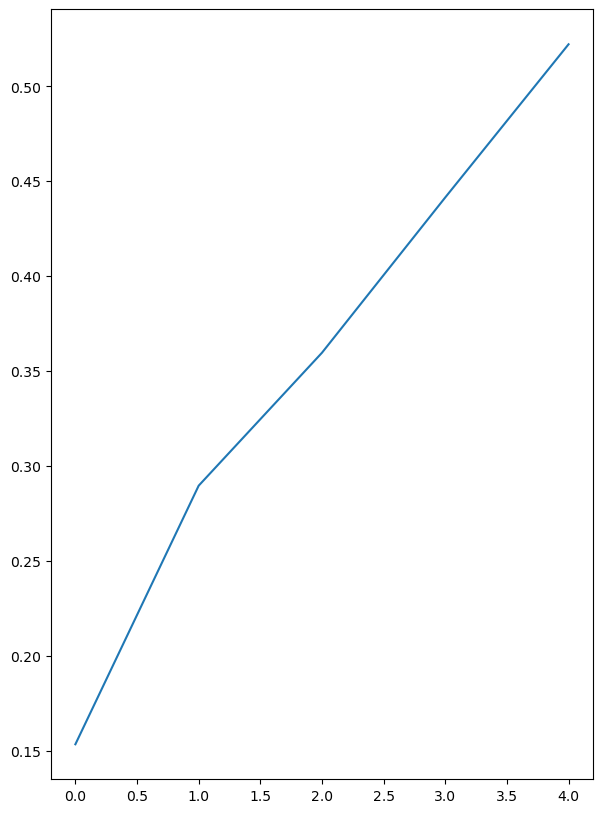

In [34]:
plt.figure(figsize=(7, 10))
plt.plot(history_tinyvgg.history['accuracy'])

In [ ]:
# tinyvgg model
model_DenseNet = Sequential([
    Input(shape=(1024   , 2, 1)),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    MaxPool2D((2, 1)),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    MaxPool2D((2, 1)),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation=relu),
    MaxPool2D((2, 1)),
    Flatten(),
    Dense(24, activation=softmax),
], name="TinyVGG")